In [ ]:
# ==============================================================================
# CELDA 1: Evaluación con embeddings usando LazyClassifier SIN SMOTE
# (Solo class_weight='balanced' en modelos que lo soporten)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_no_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (SIN SMOTE)")
    print(f"{'='*80}")
    
    try:
        # Cargar datos desde el manifest
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        
        # Convertir a DataFrame / Series para manejar los índices
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
        
        print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")
        
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    
    # Inyectar class_weight='balanced' en los modelos de LazyClassifier que lo soporten
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)
    for name, model in clf.models.items():
        if hasattr(model, 'class_weight'):
            model.class_weight = 'balanced'

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # Entrenar LazyClassifier directamente en el fold SIN SMOTE
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        # Resumen del promedio de los 5 folds para este modelo de embeddings
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model}:")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_no_smote.append(cv_summary)

if resultados_globales_no_smote:
    res_final_no_smote = pd.concat(resultados_globales_no_smote, ignore_index=True)
    res_final_no_smote = res_final_no_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (SIN SMOTE)")
    print(f"{'='*80}")
    print(res_final_no_smote.head(15).to_string(index=False))

In [ ]:
# ==============================================================================
# CELDA 2: Evaluación con embeddings usando LazyClassifier CON SMOTE
# (SMOTE aplicado SOLO en el conjunto de TRAIN del CV)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
import importlib, subprocess, sys

from imblearn.over_sampling import SMOTE


warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (CON SMOTE en TRAIN)")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # SMOTE solo en el set de Entrenamiento para evitar data leakage
        k = min(5, int(y_tr.value_counts().min()) - 1)
        if k >= 1:
            X_tr, y_tr = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr, y_tr)
        
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (CON SMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_smote.append(cv_summary)

if resultados_globales_smote:
    res_final_smote = pd.concat(resultados_globales_smote, ignore_index=True)
    res_final_smote = res_final_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON SMOTE)")
    print(f"{'='*80}")
    print(res_final_smote.head(15).to_string(index=False))


In [ ]:
# ==============================================================================
# CELDA: Evaluación con embeddings usando LazyClassifier 
# Pipeline: StandardScaler -> SMOTE (solo en el conjunto de TRAIN del CV) -> LazyClassifier
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_scaler_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model}")
    print(f"Pipeline: StandardScaler -> SMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr_raw, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val_raw, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # 1. Escalar (entrenando solo en X_tr)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_val_sc = scaler.transform(X_val_raw)
        
        # 2. SMOTE solo en el set de Entrenamiento transformado para evitar data leakage
        k = min(5, int(y_tr.value_counts().min()) - 1)
        if k >= 1:
            X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr_sc, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr
            
        # Convertir a DataFrames para LazyPredict
        X_tr_df = pd.DataFrame(X_tr_sm, columns=X.columns)
        X_val_df = pd.DataFrame(X_val_sc, columns=X.columns)
        
        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (StandardScaler + SMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_scaler_smote.append(cv_summary)

if resultados_globales_scaler_smote:
    res_final_scaler_smote = pd.concat(resultados_globales_scaler_smote, ignore_index=True)
    res_final_scaler_smote = res_final_scaler_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (StandardScaler -> SMOTE)")
    print(f"{'='*80}")
    print(res_final_scaler_smote.head(15).to_string(index=False))


In [ ]:
# ==============================================================================
# CELDA 3: Evaluación con embeddings usando LazyClassifier CON BorderlineSMOTE
# (BorderlineSMOTE aplicado SOLO en el conjunto de TRAIN del CV)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
import importlib, subprocess, sys

from imblearn.over_sampling import BorderlineSMOTE


warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_borderline = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model} (CON BorderlineSMOTE en TRAIN)")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # BorderlineSMOTE solo en el set de Entrenamiento para evitar data leakage
        min_class_count = int(y_tr.value_counts().min())
        k = min(5, min_class_count - 1)
        m = min(10, min_class_count - 1)
        
        if k >= 1 and m >= 1:
            try:
                smote = BorderlineSMOTE(random_state=42, k_neighbors=k, m_neighbors=m)
                X_tr, y_tr = smote.fit_resample(X_tr, y_tr)
            except Exception as e:
                pass
        
        models_fold, _ = clf.fit(X_tr, X_val, y_tr, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (CON BorderlineSMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_borderline.append(cv_summary)

if resultados_globales_borderline:
    res_final_borderline = pd.concat(resultados_globales_borderline, ignore_index=True)
    res_final_borderline = res_final_borderline.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS DE EMBEDDINGS (CON BorderlineSMOTE)")
    print(f"{'='*80}")
    print(res_final_borderline.head(15).to_string(index=False))


In [ ]:
# ==============================================================================
# CELDA: Evaluación con embeddings usando LazyClassifier 
# Pipeline: StandardScaler -> BorderlineSMOTE (solo en el conjunto de TRAIN del CV) -> LazyClassifier
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import BorderlineSMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_scaler_borderline = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS DEL MODELO: {emb_model}")
    print(f"Pipeline: StandardScaler -> BorderlineSMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, groups = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
        groups = np.array(groups)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        X_tr_raw, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val_raw, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # 1. Escalar (entrenando solo en X_tr)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr_raw)
        X_val_sc = scaler.transform(X_val_raw)
        
        # 2. BorderlineSMOTE solo en el set de Entrenamiento transformado para evitar data leakage
        min_class_count = int(y_tr.value_counts().min())
        k = min(5, min_class_count - 1)
        m = min(10, min_class_count - 1)
        
        if k >= 1 and m >= 1:
            try:
                smote = BorderlineSMOTE(random_state=42, k_neighbors=k, m_neighbors=m)
                X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sc, y_tr)
            except Exception as e:
                X_tr_sm, y_tr_sm = X_tr_sc, y_tr
        else:
            X_tr_sm, y_tr_sm = X_tr_sc, y_tr
            
        # Convertir a DataFrames para LazyPredict
        X_tr_df = pd.DataFrame(X_tr_sm, columns=X.columns)
        X_val_df = pd.DataFrame(X_val_sc, columns=X.columns)
        
        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (StandardScaler + BorderlineSMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_scaler_borderline.append(cv_summary)

if resultados_globales_scaler_borderline:
    res_final_scaler_borderline = pd.concat(resultados_globales_scaler_borderline, ignore_index=True)
    res_final_scaler_borderline = res_final_scaler_borderline.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL DE MODELOS (StandardScaler -> BorderlineSMOTE)")
    print(f"{'='*80}")
    print(res_final_scaler_borderline.head(15).to_string(index=False))

In [ ]:
# ==============================================================================
# EVALUACIÓN DE EMBEDDINGS: StandardScaler -> PCA (0.95) -> SMOTE -> Clasificador
# - Usa StratifiedKFold 
# - Pipeline aplicado correctamente: se ajusta (fit) en train, transforma val,
#   y luego SMOTE se aplica solo en train transformado.
# ==============================================================================

import warnings
import pandas as pd
import numpy as np
import sys
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
MODELS_TO_TEST = ["xlsr-300m", "xlsr-53", "whisper-large-encoder", "wav2vec2-large-robust", "wavlm-large", "hubert-large"]

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

resultados_globales_pca_smote = []

for emb_model in MODELS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"EVALUANDO EMBEDDINGS: {emb_model}")
    print(f"Pipeline: StandardScaler -> PCA(0.95) -> SMOTE (solo train) -> LazyClassifier")
    print(f"{'='*80}")
    
    try:
        X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, emb_model, condition=CONDITION)
        X = pd.DataFrame(X_mat)
        y = pd.Series(y_mat)
    except Exception as e:
        print(f"Error cargando {emb_model}: {e}")
        continue

    cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=f1_macro, predictions=False)

    rows = []
    
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        # 1. Escalar (entrenando solo en X_tr)
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)
        
        # 2. PCA
        pca = PCA(n_components=15, random_state=42)
        X_tr_pca = pca.fit_transform(X_tr_sc)
        X_val_pca = pca.transform(X_val_sc)
        
        # 3. SMOTE solo en train
        k = min(5, int(y_tr.value_counts().min()) - 1)
        if k >= 1:
            X_tr_sm, y_tr_sm = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_tr_pca, y_tr)
        else:
            X_tr_sm, y_tr_sm = X_tr_pca, y_tr
            
        # Convertir a DataFrames
        X_tr_df = pd.DataFrame(X_tr_sm)
        X_val_df = pd.DataFrame(X_val_pca)
        
        # 4. Entrenar y predecir
        models_fold, _ = clf.fit(X_tr_df, X_val_df, y_tr_sm, y_val)
        models_fold = models_fold.reset_index().rename(columns={"index": "Model"})
        models_fold["Fold"] = fold
        models_fold["Embedding_Model"] = emb_model
        rows.append(models_fold)
        
    if rows:
        cv_raw = pd.concat(rows, ignore_index=True)
        metricas = [c for c in ["Accuracy", "Balanced Accuracy", "F1 Score", "f1_macro", "ROC AUC"] if c in cv_raw.columns]
        sort_col = "f1_macro" if "f1_macro" in metricas else "Balanced Accuracy"
        
        cv_summary = (
            cv_raw
            .groupby(["Embedding_Model", "Model"], as_index=False)[metricas]
            .mean()
            .sort_values(sort_col, ascending=False)
        )
        print(f"\nTop 5 clasificadores para {emb_model} (PCA + SMOTE):")
        print(cv_summary.head(5).to_string(index=False))
        
        resultados_globales_pca_smote.append(cv_summary)

if resultados_globales_pca_smote:
    res_final_pca_smote = pd.concat(resultados_globales_pca_smote, ignore_index=True)
    res_final_pca_smote = res_final_pca_smote.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    print(f"\n{'='*80}")
    print("RANKING GLOBAL FINAL (StandardScaler -> PCA 0.95 -> SMOTE -> LazyClassifier)")
    print(f"{'='*80}")
    print(res_final_pca_smote.head(15).to_string(index=False))

In [9]:
# ==============================================================================
# CELDA: Grid Search CV para KNeighborsClassifier
# Pipeline: StandardScaler -> KNeighborsClassifier (SIN resampling)
# Embeddings: xlsr-300m
# Este fue el mejor resultado por ROC AUC en el barrido inicial (0.652, SIN SMOTE)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
EMB_MODEL = "xlsr-300m"

print(f"\n{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: KNeighborsClassifier")
print(f"Pipeline: StandardScaler -> KNeighborsClassifier (sin resampling, tal como ganó en el barrido)")
print(f"{'='*80}")

X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
X_knn = pd.DataFrame(X_mat)
y_knn = pd.Series(y_mat)
print(f"Shape de X: {X_knn.shape}, Shape de y: {y_knn.shape}")

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

# Grid deliberadamente chico: el GridSearch anterior (8,640 combinaciones x 15
# folds = 129,600 fits) resultó impracticable y tuvo que interrumpirse.
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan', 'cosine'],
}
# 7×2×3 = 42 combinaciones × 15 folds = 630 fits

cv_knn = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
f1_macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)

print("\nIniciando GridSearchCV...")
grid_search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring={'roc_auc': 'roc_auc', 'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    refit='roc_auc',  # optimizamos por ROC AUC, que es el criterio pedido
    cv=cv_knn,
    n_jobs=-1,
    verbose=1,
)
grid_search_knn.fit(X_knn, y_knn)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BÚSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparámetros:\n{grid_search_knn.best_params_}")
print(f"Mejor ROC AUC (CV): {grid_search_knn.best_score_:.4f}")

resultados_cv_knn = pd.DataFrame(grid_search_knn.cv_results_)
top_5_knn = resultados_cv_knn.sort_values(by="rank_test_roc_auc").head(5)
print("\nTop 5 configuraciones de Hiperparámetros:")
for idx, row in top_5_knn.iterrows():
    print(f"\nRank {row['rank_test_roc_auc']}:")
    print(f"  ROC AUC:  {row['mean_test_roc_auc']:.4f} (±{row['std_test_roc_auc']:.4f})")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parámetros: {row['params']}")


OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo de Embeddings: xlsr-300m
Clasificador: KNeighborsClassifier
Pipeline: StandardScaler -> KNeighborsClassifier (sin resampling, tal como ganó en el barrido)
Shape de X: (79, 1024), Shape de y: (79,)

Iniciando GridSearchCV...
Fitting 15 folds for each of 42 candidates, totalling 630 fits

RESULTADOS DE LA BÚSQUEDA
Mejores Hiperparámetros:
{'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Mejor ROC AUC (CV): 0.7155

Top 5 configuraciones de Hiperparámetros:

Rank 1:
  ROC AUC:  0.7155 (±0.1101)
  F1 Macro: 0.5852 (±0.1054)
  Accuracy: 0.7303 (±0.0566)
  Parámetros: {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}

Rank 2:
  ROC AUC:  0.7072 (±0.1369)
  F1 Macro: 0.6112 (±0.1138)
  Accuracy: 0.7469 (±0.0640)
  Parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}

Rank 3:
  ROC AUC:  0.7065 (±0.0678)
  F1 Macro: 0.5917 (±0.0555)
  Accurac


EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: xlsr-300m | Clasificador: KNeighborsClassifier (Optimizado)
Hiperparámetros usados: {'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'distance'}

Iniciando Evaluación mediante cross_validate...

RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.6052 (±0.1306)
Accuracy Promedio: 0.7317 (±0.0884)
ROC AUC Promedio:  0.7033 (±0.1302)

Scores por fold guardados en: scores_knn_xlsr300m.csv

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


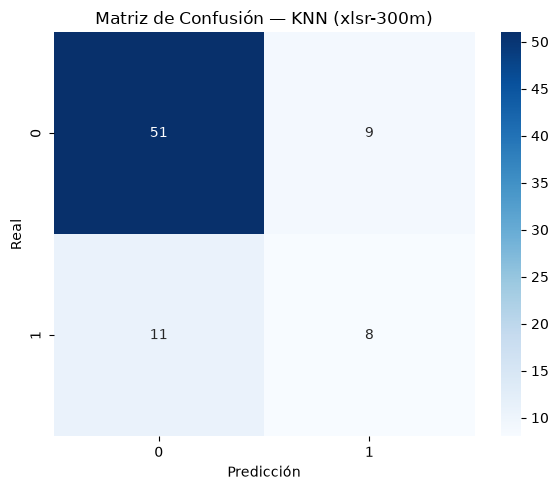

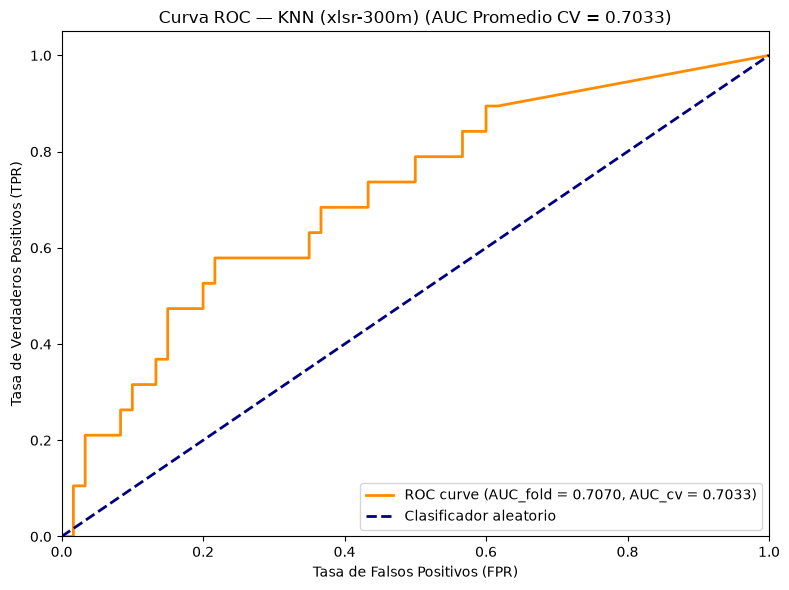

In [10]:
# ==============================================================================
# CELDA: Evaluación Final de KNeighborsClassifier optimizado
# Pipeline: StandardScaler -> KNeighborsClassifier (sin resampling)
# Embeddings: xlsr-300m
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# Requiere haber ejecutado la celda de GridSearchCV anterior (usa grid_search_knn)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, f1_score, make_scorer, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

N_SPLITS = 5
N_REPEATS = 10

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL ({N_REPEATS} repeticiones x {N_SPLITS} folds)")
print(f"Modelo de Embeddings: xlsr-300m | Clasificador: KNeighborsClassifier (Optimizado)")
print(f"{'='*80}")

pipeline_knn_final = clone(pipeline_knn).set_params(**grid_search_knn.best_params_)
print(f"Hiperparámetros usados: {grid_search_knn.best_params_}")

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
}

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

print("\nIniciando Evaluación mediante cross_validate...")
scores_knn = cross_validate(pipeline_knn_final, X_knn, y_knn, cv=cv, scoring=scoring,
                             n_jobs=-1, error_score=np.nan)

mean_f1 = np.nanmean(scores_knn['test_f1_macro']); std_f1 = np.nanstd(scores_knn['test_f1_macro'])
mean_acc = np.nanmean(scores_knn['test_accuracy']); std_acc = np.nanstd(scores_knn['test_accuracy'])
mean_roc = np.nanmean(scores_knn['test_roc_auc']); std_roc = np.nanstd(scores_knn['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio: {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:  {mean_roc:.4f} (±{std_roc:.4f})")

results_df_knn = pd.DataFrame({
    'fold': range(1, len(scores_knn['test_f1_macro']) + 1),
    'f1_macro': scores_knn['test_f1_macro'],
    'accuracy': scores_knn['test_accuracy'],
    'roc_auc': scores_knn['test_roc_auc'],
})
results_df_knn.to_csv('scores_knn_xlsr300m.csv', index=False)
print("\nScores por fold guardados en: scores_knn_xlsr300m.csv")

# ── Gráficos (Matriz de Confusión y Curva ROC) usando 1 partición de 5 folds ──
print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

cv_plot = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_prob_plot_knn = cross_val_predict(
    pipeline_knn_final, X_knn, y_knn, cv=cv_plot,
    method='predict_proba', n_jobs=-1
)
classes = np.unique(y_knn)
y_pred_plot_knn = classes[np.argmax(y_prob_plot_knn, axis=1)]

cm = confusion_matrix(y_knn, y_pred_plot_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión — KNN (xlsr-300m)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_knn_xlsr300m.png', dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_knn, y_prob_plot_knn[:, 1])
fold_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC — KNN (xlsr-300m) (AUC Promedio CV = {mean_roc:.4f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_knn_xlsr300m.png', dpi=150)
plt.show()

In [11]:
# ==============================================================================
# CELDA: Grid Search CV para SVC
# Pipeline: BorderlineSMOTE (en crudo) -> StandardScaler -> SVC
# Embeddings: wav2vec2-large-robust
# Este fue el mejor resultado por ROC AUC en el barrido inicial (0.651, BorderlineSMOTE)
# El orden (SMOTE antes de escalar) replica exactamente el pipeline ganador:
# LazyPredict siempre escala internamente antes de ajustar cada clasificador,
# así que "BorderlineSMOTE" (celda 3) en realidad fue SMOTE en crudo + escalado
# interno + SVC — no SMOTE sobre datos ya escalados (esa es la celda 4).
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: SVC")
print(f"Pipeline: BorderlineSMOTE (crudo) -> StandardScaler -> SVC")
print(f"{'='*80}")

X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
X_svc = pd.DataFrame(X_mat)
y_svc = pd.Series(y_mat)
print(f"Shape de X: {X_svc.shape}, Shape de y: {y_svc.shape}")

# Cálculo seguro de vecinos para BorderlineSMOTE asumiendo 5 folds (queda ~75% en train)
min_samples_in_train = int(y_svc.value_counts().min() * 0.75)
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

pipeline_svc = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=42)),
])

# Grid chico a propósito (ver nota en la celda de KNN sobre el GridSearch anterior)
param_grid_svc = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma': ['scale', 'auto'],
    'clf__class_weight': [None, 'balanced'],
}
# 4×2×2×2 = 32 combinaciones × 15 folds = 480 fits

cv_svc = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
f1_macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)

print("\nIniciando GridSearchCV...")
grid_search_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid_svc,
    scoring={'roc_auc': 'roc_auc', 'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    refit='roc_auc',  # optimizamos por ROC AUC, que es el criterio pedido
    cv=cv_svc,
    n_jobs=-1,
    verbose=1,
    error_score=np.nan,
)
grid_search_svc.fit(X_svc, y_svc)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BÚSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparámetros:\n{grid_search_svc.best_params_}")
print(f"Mejor ROC AUC (CV): {grid_search_svc.best_score_:.4f}")

resultados_cv_svc = pd.DataFrame(grid_search_svc.cv_results_)
top_5_svc = resultados_cv_svc.sort_values(by="rank_test_roc_auc").head(5)
print("\nTop 5 configuraciones de Hiperparámetros:")
for idx, row in top_5_svc.iterrows():
    print(f"\nRank {row['rank_test_roc_auc']}:")
    print(f"  ROC AUC:  {row['mean_test_roc_auc']:.4f} (±{row['std_test_roc_auc']:.4f})")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parámetros: {row['params']}")


OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: SVC
Pipeline: BorderlineSMOTE (crudo) -> StandardScaler -> SVC
Shape de X: (79, 1024), Shape de y: (79,)

Iniciando GridSearchCV...
Fitting 15 folds for each of 32 candidates, totalling 480 fits

RESULTADOS DE LA BÚSQUEDA
Mejores Hiperparámetros:
{'clf__C': 1, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejor ROC AUC (CV): 0.6639

Top 5 configuraciones de Hiperparámetros:

Rank 1:
  ROC AUC:  0.6639 (±0.0949)
  F1 Macro: 0.5645 (±0.1137)
  Accuracy: 0.7053 (±0.0893)
  Parámetros: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Rank 1:
  ROC AUC:  0.6639 (±0.0937)
  F1 Macro: 0.5645 (±0.1137)
  Accuracy: 0.7053 (±0.0893)
  Parámetros: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}

Rank 1:
  ROC AUC:  0.6639 (±0.0937)
  F1 Macro: 0.5645 (±0.1137)
  Accuracy: 0.7053 (±


EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: wav2vec2-large-robust | Clasificador: SVC (Optimizado)
Hiperparámetros usados: {'clf__C': 1, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Iniciando Evaluación mediante cross_validate...

RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.5494 (±0.1180)
Accuracy Promedio: 0.6886 (±0.0890)
ROC AUC Promedio:  0.6511 (±0.1218)

Scores por fold guardados en: scores_svc_wav2vec2robust.csv

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


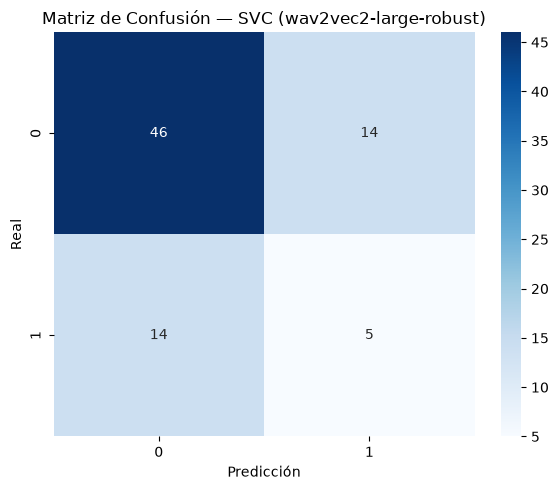

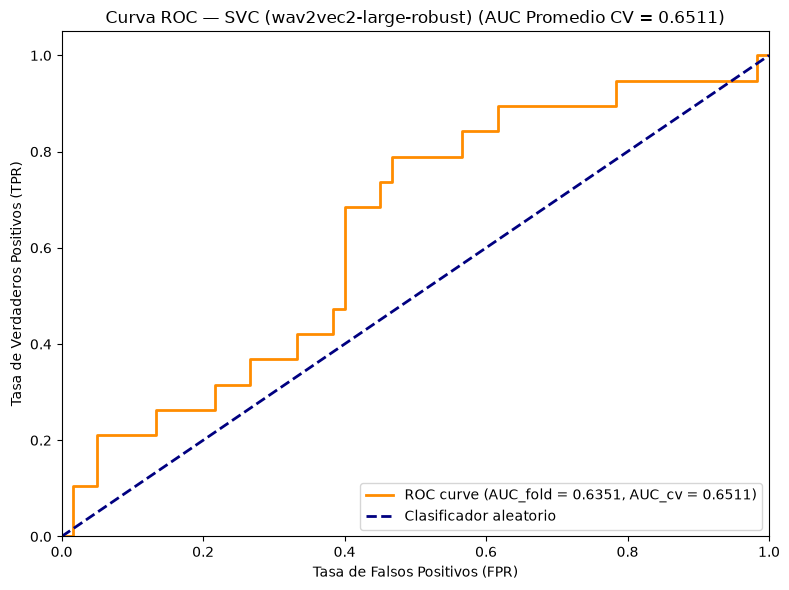

In [12]:
# ==============================================================================
# CELDA: Evaluación Final de SVC optimizado
# Pipeline: BorderlineSMOTE (crudo) -> StandardScaler -> SVC
# Embeddings: wav2vec2-large-robust
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# Requiere haber ejecutado la celda de GridSearchCV anterior (usa grid_search_svc)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score, make_scorer, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

N_SPLITS = 5
N_REPEATS = 10

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL ({N_REPEATS} repeticiones x {N_SPLITS} folds)")
print(f"Modelo de Embeddings: wav2vec2-large-robust | Clasificador: SVC (Optimizado)")
print(f"{'='*80}")

pipeline_svc_final = clone(pipeline_svc).set_params(**grid_search_svc.best_params_)
print(f"Hiperparámetros usados: {grid_search_svc.best_params_}")

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
}

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

print("\nIniciando Evaluación mediante cross_validate...")
scores_svc = cross_validate(pipeline_svc_final, X_svc, y_svc, cv=cv, scoring=scoring,
                             n_jobs=-1, error_score=np.nan)

mean_f1 = np.nanmean(scores_svc['test_f1_macro']); std_f1 = np.nanstd(scores_svc['test_f1_macro'])
mean_acc = np.nanmean(scores_svc['test_accuracy']); std_acc = np.nanstd(scores_svc['test_accuracy'])
mean_roc = np.nanmean(scores_svc['test_roc_auc']); std_roc = np.nanstd(scores_svc['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio: {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:  {mean_roc:.4f} (±{std_roc:.4f})")

results_df_svc = pd.DataFrame({
    'fold': range(1, len(scores_svc['test_f1_macro']) + 1),
    'f1_macro': scores_svc['test_f1_macro'],
    'accuracy': scores_svc['test_accuracy'],
    'roc_auc': scores_svc['test_roc_auc'],
})
results_df_svc.to_csv('scores_svc_wav2vec2robust.csv', index=False)
print("\nScores por fold guardados en: scores_svc_wav2vec2robust.csv")

# ── Gráficos (Matriz de Confusión y Curva ROC) — loop manual para evitar que ──
# ── el SMOTE de una repetición contamine la partición de otra ───────────────
print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

classes = np.unique(y_svc)
cv_plot = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_prob_all_svc = np.zeros((len(y_svc), len(classes)))
y_pred_all_svc = np.empty(len(y_svc), dtype=y_svc.dtype)

for train_idx, test_idx in cv_plot.split(X_svc, y_svc):
    X_train, X_test = X_svc.iloc[train_idx], X_svc.iloc[test_idx]
    y_train = y_svc.iloc[train_idx]

    pipeline_svc_final.fit(X_train, y_train)
    y_prob_all_svc[test_idx] = pipeline_svc_final.predict_proba(X_test)
    y_pred_all_svc[test_idx] = pipeline_svc_final.predict(X_test)

cm = confusion_matrix(y_svc, y_pred_all_svc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión — SVC (wav2vec2-large-robust)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_svc_wav2vec2robust.png', dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_svc, y_prob_all_svc[:, 1])
fold_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC — SVC (wav2vec2-large-robust) (AUC Promedio CV = {mean_roc:.4f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_svc_wav2vec2robust.png', dpi=150)
plt.show()

In [13]:
# ==============================================================================
# CELDA: Grid Search CV para NuSVC
# Pipeline: BorderlineSMOTE (en crudo) -> StandardScaler -> NuSVC
# Embeddings: wav2vec2-large-robust
# Tercer mejor resultado por ROC AUC en el barrido inicial (0.646, BorderlineSMOTE)
# ==============================================================================
import warnings
import pandas as pd
import numpy as np
import sys
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import NuSVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE

warnings.filterwarnings("ignore")

# Añadir el path para importar la función de carga de embeddings (v2, por segmento)
sys.path.append('/home/ci2dt2-ai/Proyectos/Psiquiatria')
from embedding_pipeline_5s import load_embeddings_for_classification

EMBEDDINGS_DIR = "/home/ci2dt2-ai/Proyectos/Psiquiatria/Clasificación Final/Ansiedad/embeddings_v2/"
CONDITION = "ansiedad"
EMB_MODEL = "wav2vec2-large-robust"

print(f"\n{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)")
print(f"Modelo de Embeddings: {EMB_MODEL}")
print(f"Clasificador: NuSVC")
print(f"Pipeline: BorderlineSMOTE (crudo) -> StandardScaler -> NuSVC")
print(f"{'='*80}")

X_mat, y_mat, _ = load_embeddings_for_classification(EMBEDDINGS_DIR, EMB_MODEL, condition=CONDITION)
X_nusvc = pd.DataFrame(X_mat)
y_nusvc = pd.Series(y_mat)
print(f"Shape de X: {X_nusvc.shape}, Shape de y: {y_nusvc.shape}")

# Cálculo seguro de vecinos para BorderlineSMOTE asumiendo 5 folds (queda ~75% en train)
min_samples_in_train = int(y_nusvc.value_counts().min() * 0.75)
k_safe = max(1, min(5, min_samples_in_train - 1))
m_safe = max(1, min(10, min_samples_in_train - 1))

pipeline_nusvc = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42, k_neighbors=k_safe, m_neighbors=m_safe)),
    ('scaler', StandardScaler()),
    ('clf', NuSVC(probability=True, random_state=42)),
])

# Grid chico a propósito (ver nota en la celda de KNN sobre el GridSearch anterior)
# nu se mantiene <= 0.9 porque, tras el balanceo de BorderlineSMOTE, valores muy
# cercanos a 1 suelen quedar fuera de la región factible y NuSVC lanza excepción
# (por eso también se usa error_score=np.nan más abajo, para no abortar el grid).
param_grid_nusvc = {
    'clf__nu': [0.1, 0.3, 0.5, 0.7, 0.9],
    'clf__kernel': ['rbf', 'linear'],
    'clf__gamma': ['scale', 'auto'],
    'clf__class_weight': [None, 'balanced'],
}
# 5×2×2×2 = 40 combinaciones × 15 folds = 600 fits

cv_nusvc = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
f1_macro_scorer = make_scorer(f1_score, average="macro", zero_division=0)

print("\nIniciando GridSearchCV...")
grid_search_nusvc = GridSearchCV(
    estimator=pipeline_nusvc,
    param_grid=param_grid_nusvc,
    scoring={'roc_auc': 'roc_auc', 'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    refit='roc_auc',  # optimizamos por ROC AUC, que es el criterio pedido
    cv=cv_nusvc,
    n_jobs=-1,
    verbose=1,
    error_score=np.nan,
)
grid_search_nusvc.fit(X_nusvc, y_nusvc)

print(f"\n{'='*80}")
print("RESULTADOS DE LA BÚSQUEDA")
print(f"{'='*80}")
print(f"Mejores Hiperparámetros:\n{grid_search_nusvc.best_params_}")
print(f"Mejor ROC AUC (CV): {grid_search_nusvc.best_score_:.4f}")

resultados_cv_nusvc = pd.DataFrame(grid_search_nusvc.cv_results_)
top_5_nusvc = resultados_cv_nusvc.sort_values(by="rank_test_roc_auc").head(5)
print("\nTop 5 configuraciones de Hiperparámetros:")
for idx, row in top_5_nusvc.iterrows():
    print(f"\nRank {row['rank_test_roc_auc']}:")
    print(f"  ROC AUC:  {row['mean_test_roc_auc']:.4f} (±{row['std_test_roc_auc']:.4f})")
    print(f"  F1 Macro: {row['mean_test_f1_macro']:.4f} (±{row['std_test_f1_macro']:.4f})")
    print(f"  Accuracy: {row['mean_test_accuracy']:.4f} (±{row['std_test_accuracy']:.4f})")
    print(f"  Parámetros: {row['params']}")


OPTIMIZACIÓN DE HIPERPARÁMETROS (GridSearchCV)
Modelo de Embeddings: wav2vec2-large-robust
Clasificador: NuSVC
Pipeline: BorderlineSMOTE (crudo) -> StandardScaler -> NuSVC
Shape de X: (79, 1024), Shape de y: (79,)

Iniciando GridSearchCV...
Fitting 15 folds for each of 40 candidates, totalling 600 fits

RESULTADOS DE LA BÚSQUEDA
Mejores Hiperparámetros:
{'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.7}
Mejor ROC AUC (CV): 0.6685

Top 5 configuraciones de Hiperparámetros:

Rank 1:
  ROC AUC:  0.6685 (±0.0964)
  F1 Macro: 0.5792 (±0.1118)
  Accuracy: 0.7094 (±0.0982)
  Parámetros: {'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.7}

Rank 1:
  ROC AUC:  0.6685 (±0.0964)
  F1 Macro: 0.5792 (±0.1118)
  Accuracy: 0.7094 (±0.0982)
  Parámetros: {'clf__class_weight': None, 'clf__gamma': 'auto', 'clf__kernel': 'rbf', 'clf__nu': 0.7}

Rank 1:
  ROC AUC:  0.6685 (±0.0964)
  F1 Macro: 0.5792 (±0.1118)
  Accuracy: 0.7094 (


EVALUACIÓN FINAL (10 repeticiones x 5 folds)
Modelo de Embeddings: wav2vec2-large-robust | Clasificador: NuSVC (Optimizado)
Hiperparámetros usados: {'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'clf__nu': 0.7}

Iniciando Evaluación mediante cross_validate...

RESULTADOS FINALES DE LA EVALUACIÓN
F1 Macro Promedio: 0.5631 (±0.1030)
Accuracy Promedio: 0.6932 (±0.0866)
ROC AUC Promedio:  0.6500 (±0.1296)

Scores por fold guardados en: scores_nusvc_wav2vec2robust.csv

Generando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...


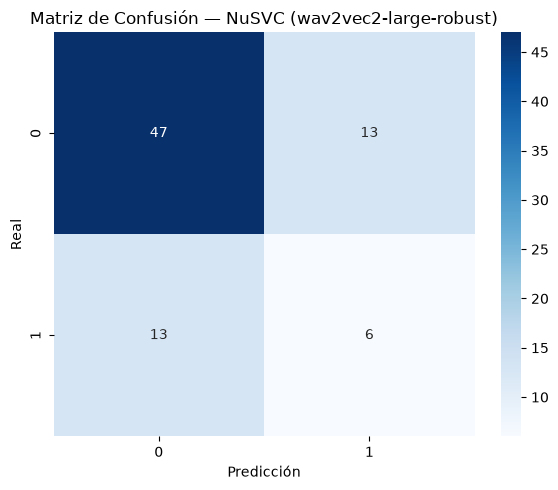

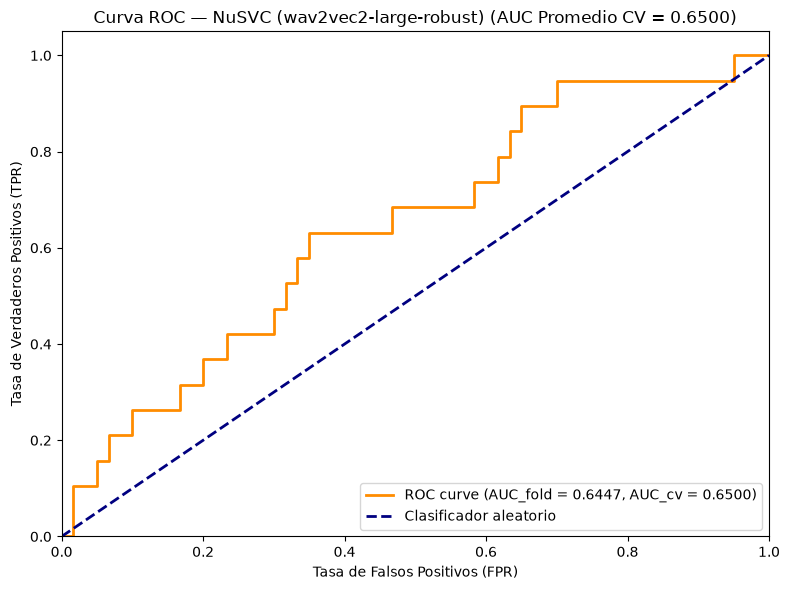

In [14]:
# ==============================================================================
# CELDA: Evaluación Final de NuSVC optimizado
# Pipeline: BorderlineSMOTE (crudo) -> StandardScaler -> NuSVC
# Embeddings: wav2vec2-large-robust
# Repeticiones: 10 (10 repeticiones x 5 folds = 50 iteraciones)
# Requiere haber ejecutado la celda de GridSearchCV anterior (usa grid_search_nusvc)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score, make_scorer, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

N_SPLITS = 5
N_REPEATS = 10

print(f"\n{'='*80}")
print(f"EVALUACIÓN FINAL ({N_REPEATS} repeticiones x {N_SPLITS} folds)")
print(f"Modelo de Embeddings: wav2vec2-large-robust | Clasificador: NuSVC (Optimizado)")
print(f"{'='*80}")

pipeline_nusvc_final = clone(pipeline_nusvc).set_params(**grid_search_nusvc.best_params_)
print(f"Hiperparámetros usados: {grid_search_nusvc.best_params_}")

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
}

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

print("\nIniciando Evaluación mediante cross_validate...")
scores_nusvc = cross_validate(pipeline_nusvc_final, X_nusvc, y_nusvc, cv=cv, scoring=scoring,
                               n_jobs=-1, error_score=np.nan)

mean_f1 = np.nanmean(scores_nusvc['test_f1_macro']); std_f1 = np.nanstd(scores_nusvc['test_f1_macro'])
mean_acc = np.nanmean(scores_nusvc['test_accuracy']); std_acc = np.nanstd(scores_nusvc['test_accuracy'])
mean_roc = np.nanmean(scores_nusvc['test_roc_auc']); std_roc = np.nanstd(scores_nusvc['test_roc_auc'])

print(f"\n{'='*80}")
print("RESULTADOS FINALES DE LA EVALUACIÓN")
print(f"{'='*80}")
print(f"F1 Macro Promedio: {mean_f1:.4f} (±{std_f1:.4f})")
print(f"Accuracy Promedio: {mean_acc:.4f} (±{std_acc:.4f})")
print(f"ROC AUC Promedio:  {mean_roc:.4f} (±{std_roc:.4f})")

results_df_nusvc = pd.DataFrame({
    'fold': range(1, len(scores_nusvc['test_f1_macro']) + 1),
    'f1_macro': scores_nusvc['test_f1_macro'],
    'accuracy': scores_nusvc['test_accuracy'],
    'roc_auc': scores_nusvc['test_roc_auc'],
})
results_df_nusvc.to_csv('scores_nusvc_wav2vec2robust.csv', index=False)
print("\nScores por fold guardados en: scores_nusvc_wav2vec2robust.csv")

# ── Gráficos (Matriz de Confusión y Curva ROC) — loop manual para evitar que ──
# ── el SMOTE de una repetición contamine la partición de otra ───────────────
print("\nGenerando gráficos (Matriz de Confusión y Curva ROC) usando 5 folds representativos...")

classes = np.unique(y_nusvc)
cv_plot = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
y_prob_all_nusvc = np.zeros((len(y_nusvc), len(classes)))
y_pred_all_nusvc = np.empty(len(y_nusvc), dtype=y_nusvc.dtype)

for train_idx, test_idx in cv_plot.split(X_nusvc, y_nusvc):
    X_train, X_test = X_nusvc.iloc[train_idx], X_nusvc.iloc[test_idx]
    y_train = y_nusvc.iloc[train_idx]

    pipeline_nusvc_final.fit(X_train, y_train)
    y_prob_all_nusvc[test_idx] = pipeline_nusvc_final.predict_proba(X_test)
    y_pred_all_nusvc[test_idx] = pipeline_nusvc_final.predict(X_test)

cm = confusion_matrix(y_nusvc, y_pred_all_nusvc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión — NuSVC (wav2vec2-large-robust)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix_nusvc_wav2vec2robust.png', dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_nusvc, y_prob_all_nusvc[:, 1])
fold_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC_fold = {fold_auc:.4f}, AUC_cv = {mean_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curva ROC — NuSVC (wav2vec2-large-robust) (AUC Promedio CV = {mean_roc:.4f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_nusvc_wav2vec2robust.png', dpi=150)
plt.show()